In [1]:
# NB02b: Forensic Exploration Supplementary – Co-occurrence, Source Bias, Image Quality & Annotation Checks

# 0.1 Import libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.notebook import tqdm
from PIL import Image
import cv2

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.max_open_warning': 0, 'font.size': 12})

# 0.2 Define paths
PROJECT_ROOT = Path("../")
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
TRAIN_IMG_DIR = PROCESSED_DIR / "images" / "train"
TRAIN_LBL_DIR = PROCESSED_DIR / "labels" / "train"

CLASS_MAP = {
    0: "hardhat",
    1: "no-hardhat",
    2: "vest",
    3: "no-vest",
    4: "person"
}

# 0.3 Load bounding boxes into DataFrame (same as NB02)
bbox_data = []
label_files = list(TRAIN_LBL_DIR.glob("*.txt"))

for lbl_path in tqdm(label_files, desc="Parsing labels"):
    if not lbl_path.exists() or lbl_path.stat().st_size == 0:
        continue
    with open(lbl_path, "r") as f:
        lines = f.readlines()
    for line in lines:
        parts = line.strip().split()
        if len(parts) == 5:
            cls_id = int(parts[0])
            xc, yc, w, h = map(float, parts[1:])
            bbox_data.append({
                "image_id": lbl_path.stem,
                "class_id": cls_id,
                "class_name": CLASS_MAP.get(cls_id, f"unknown_{cls_id}"),
                "x_center": xc,
                "y_center": yc,
                "width": w,
                "height": h,
                "area": w * h
            })

df = pd.DataFrame(bbox_data)

# 0.4 Add source column based on image filename prefix
def get_source(image_id):
    if image_id.startswith("css_"):
        return "Roboflow CSS"
    elif image_id.startswith("shwd_"):
        return "SHWD"
    elif image_id.startswith("pictor_"):
        return "Pictor-PPE"
    else:
        return "Unknown"

df["source"] = df["image_id"].apply(get_source)
print(f"Sources: {df['source'].unique()}")

Parsing labels:   0%|          | 0/8691 [00:00<?, ?it/s]

Sources: ['Roboflow CSS' 'Pictor-PPE' 'SHWD']


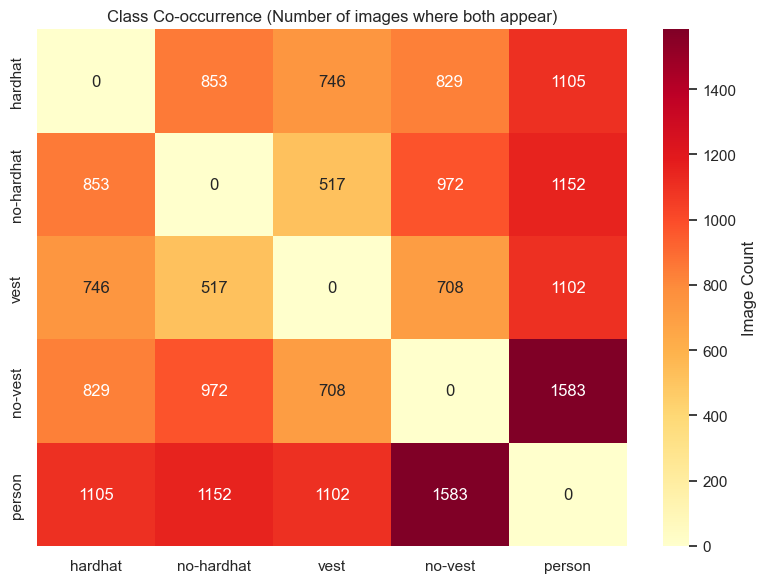

In [2]:
from itertools import combinations

# Group by image_id and collect class names per image
class_sets = df.groupby("image_id")["class_name"].apply(set).reset_index()
class_list = list(CLASS_MAP.values())

# Initialize co-occurrence matrix
co_occurrence = pd.DataFrame(0, index=class_list, columns=class_list)

# Fill matrix
for _, row in class_sets.iterrows():
    classes = row["class_name"]
    for c1, c2 in combinations(classes, 2):
        co_occurrence.loc[c1, c2] += 1
        co_occurrence.loc[c2, c1] += 1

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(co_occurrence, annot=True, fmt="d", cmap="YlOrRd", cbar_kws={'label': 'Image Count'})
plt.title("Class Co-occurrence (Number of images where both appear)")
plt.tight_layout()
plt.show()

## 2. Per‑Source Class Distribution

Different datasets may skew certain classes. Visualizing class proportions by source helps identify biases.

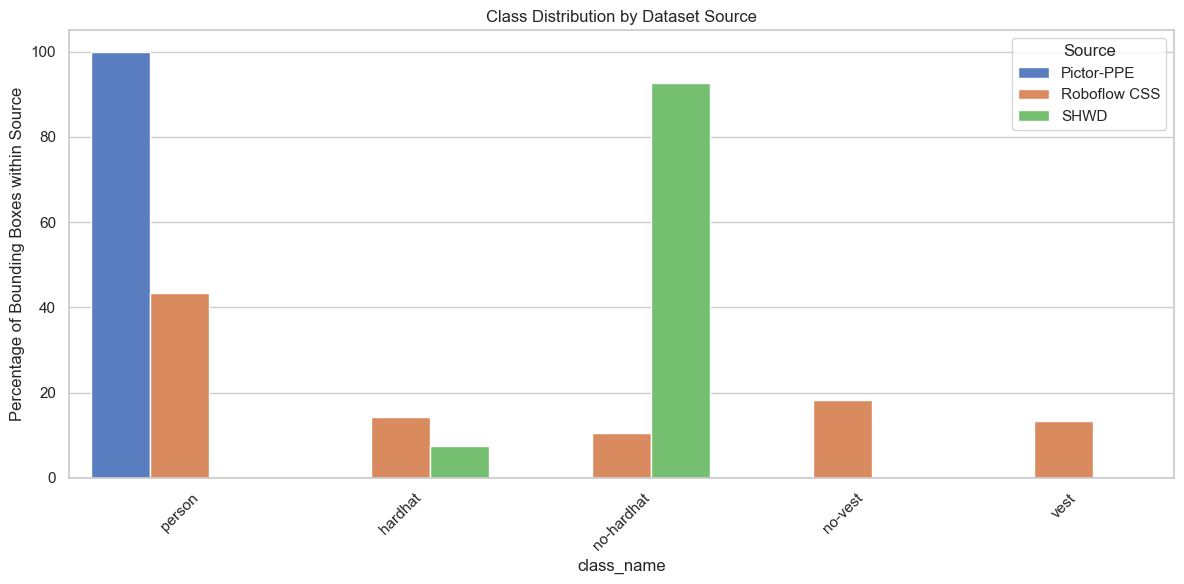

In [3]:
# Count per class and source
source_class_counts = df.groupby(["source", "class_name"]).size().reset_index(name="count")

# Normalize within each source to get percentages
source_totals = source_class_counts.groupby("source")["count"].transform("sum")
source_class_counts["percent"] = source_class_counts["count"] / source_totals * 100

# Plot grouped bar chart
plt.figure(figsize=(12, 6))
sns.barplot(data=source_class_counts, x="class_name", y="percent", hue="source")
plt.title("Class Distribution by Dataset Source")
plt.ylabel("Percentage of Bounding Boxes within Source")
plt.xticks(rotation=45)
plt.legend(title="Source")
plt.tight_layout()
plt.show()

## 3. Image Quality Analysis

We need to inspect image resolution, brightness, and potential issues (low resolution, dark, blurry). We'll compute statistics on the training images and generate visual samples.

Reading image sizes:   0%|          | 0/8691 [00:00<?, ?it/s]

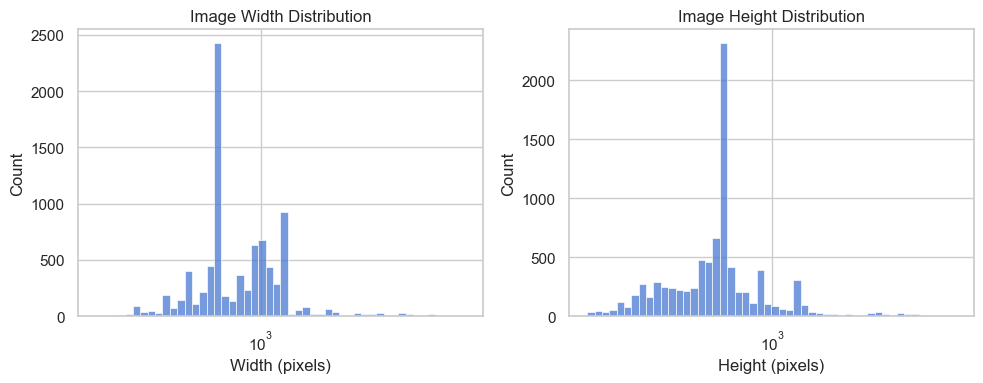

In [4]:
# Get all image file paths
img_files = list(TRAIN_IMG_DIR.glob("*.jpg")) + list(TRAIN_IMG_DIR.glob("*.png"))
widths, heights = [], []

for img_path in tqdm(img_files, desc="Reading image sizes"):
    with Image.open(img_path) as img:
        w, h = img.size
        widths.append(w)
        heights.append(h)

plt.figure(figsize=(10, 4))
plt.subplot(1,2,1)
sns.histplot(widths, bins=50, log_scale=True)
plt.title("Image Width Distribution")
plt.xlabel("Width (pixels)")

plt.subplot(1,2,2)
sns.histplot(heights, bins=50, log_scale=True)
plt.title("Image Height Distribution")
plt.xlabel("Height (pixels)")
plt.tight_layout()
plt.show()

## 3.2 Brightness & Contrast (Sample)

We'll compute average brightness and contrast for a random subset to detect very dark or washed‑out images.

  0%|          | 0/1000 [00:00<?, ?it/s]

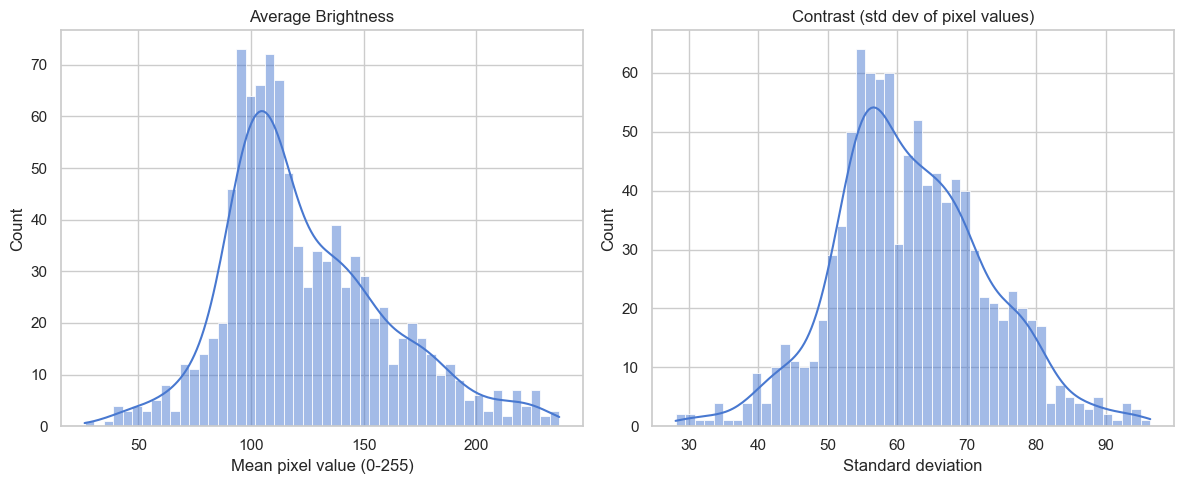

In [5]:
import random

# Sample 1000 images (or all if small)
sample_imgs = random.sample(img_files, min(1000, len(img_files)))

brightness = []
contrast = []

for img_path in tqdm(sample_imgs):
    img = cv2.imread(str(img_path))
    if img is None:
        continue
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    brightness.append(gray.mean())
    contrast.append(gray.std())

plt.figure(figsize=(12, 5))
plt.subplot(1,2,1)
sns.histplot(brightness, bins=50, kde=True)
plt.title("Average Brightness")
plt.xlabel("Mean pixel value (0-255)")

plt.subplot(1,2,2)
sns.histplot(contrast, bins=50, kde=True)
plt.title("Contrast (std dev of pixel values)")
plt.xlabel("Standard deviation")
plt.tight_layout()
plt.show()

## 3.3 Visual Sample Grids with Bounding Boxes

We'll generate a 4×4 grid of images with bounding boxes from each source to visually inspect quality and potential annotation issues.

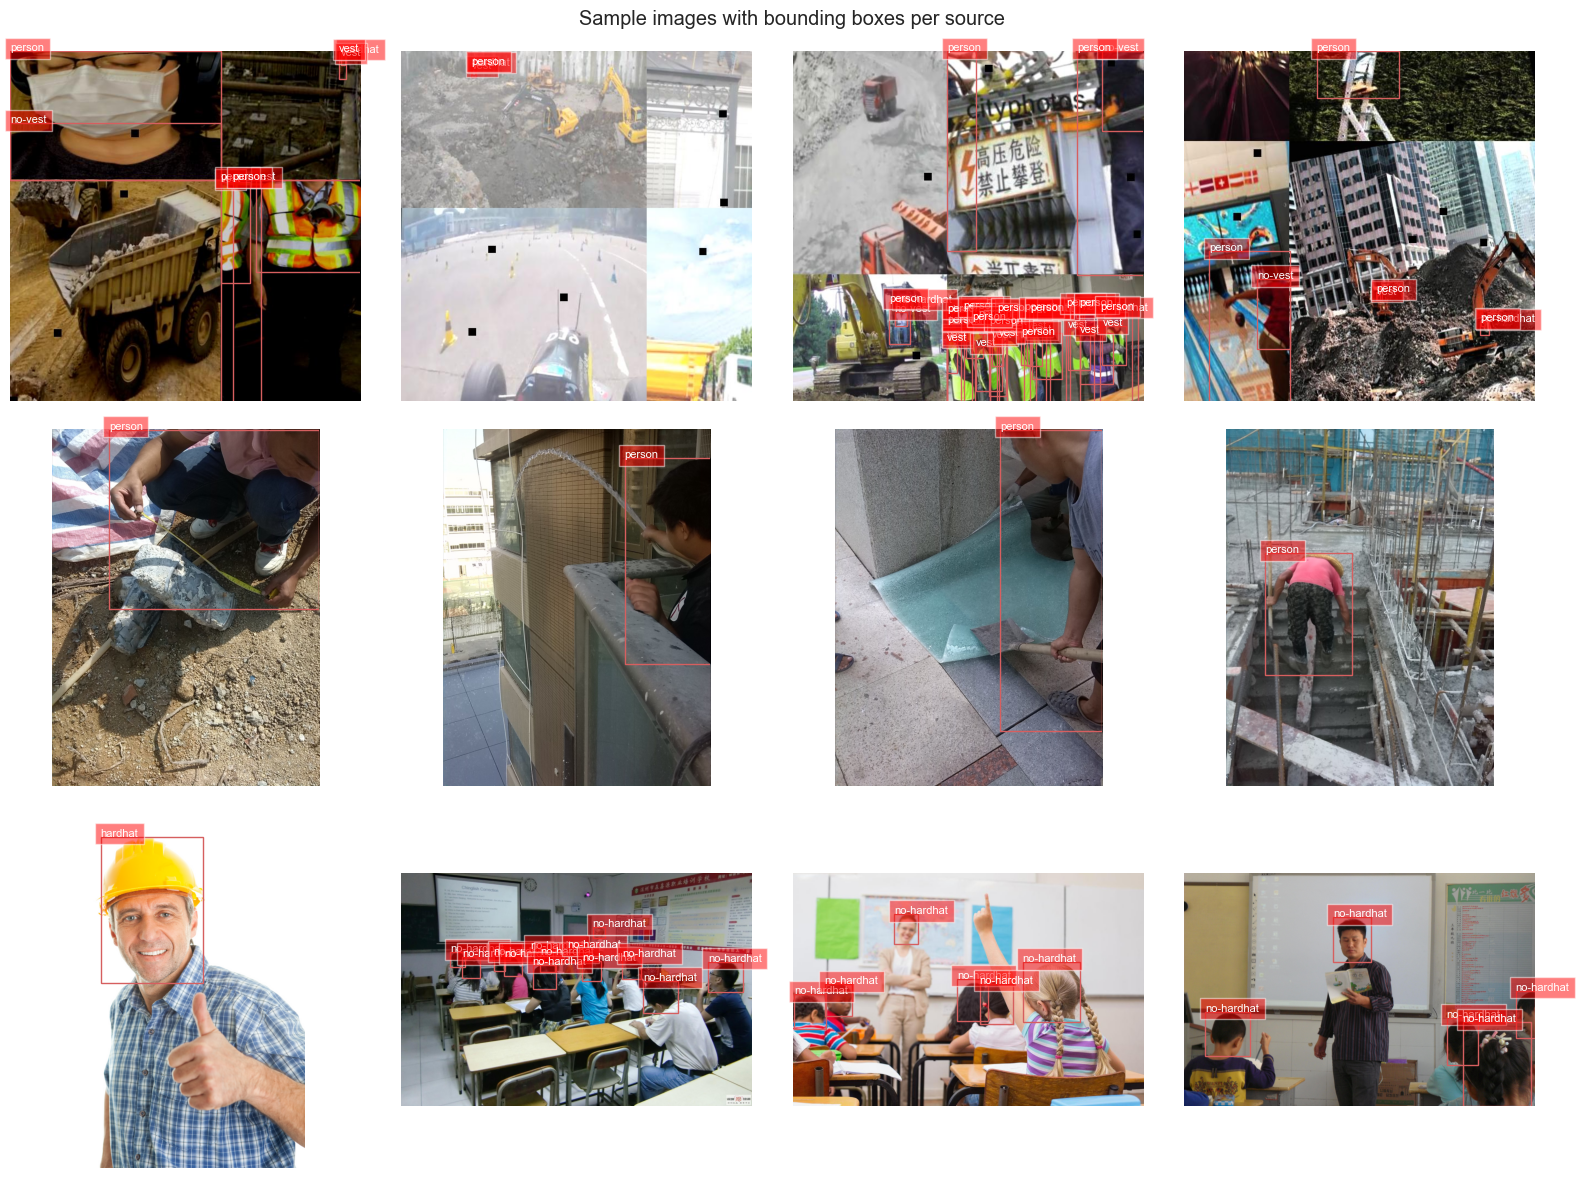

In [6]:
import matplotlib.patches as patches
from PIL import ImageDraw

def draw_bbox_on_image(img_path, label_path, ax, class_map):
    img = Image.open(img_path).convert("RGB")
    with open(label_path, "r") as f:
        lines = f.readlines()
    ax.imshow(img)
    for line in lines:
        parts = line.strip().split()
        if len(parts) != 5:
            continue
        cls_id = int(parts[0])
        xc, yc, w, h = map(float, parts[1:])
        x1 = (xc - w/2) * img.width
        y1 = (yc - h/2) * img.height
        x2 = (xc + w/2) * img.width
        y2 = (yc + h/2) * img.height
        rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, linewidth=1, edgecolor='r', facecolor='none')
        ax.add_patch(rect)
        ax.text(x1, y1, class_map[cls_id], fontsize=8, color='white', bbox=dict(facecolor='red', alpha=0.5))
    ax.axis('off')

# For each source, pick 4 random images (or less if not enough)
sources = df['source'].unique()
n_per_source = 4

fig, axes = plt.subplots(len(sources), n_per_source, figsize=(n_per_source*4, len(sources)*4))
if len(sources) == 1:
    axes = [axes]
for i, source in enumerate(sources):
    images_in_source = [f for f in img_files if get_source(f.stem) == source]
    selected = random.sample(images_in_source, min(n_per_source, len(images_in_source)))
    for j, img_path in enumerate(selected):
        label_path = TRAIN_LBL_DIR / (img_path.stem + ".txt")
        ax = axes[i][j] if len(sources) > 1 else axes[j]
        draw_bbox_on_image(img_path, label_path, ax, CLASS_MAP)
    # Fill remaining subplots if fewer than n_per_source
    for j in range(len(selected), n_per_source):
        ax = axes[i][j] if len(sources) > 1 else axes[j]
        ax.axis('off')
        ax.set_title("No image")
plt.suptitle("Sample images with bounding boxes per source")
plt.tight_layout()
plt.show()

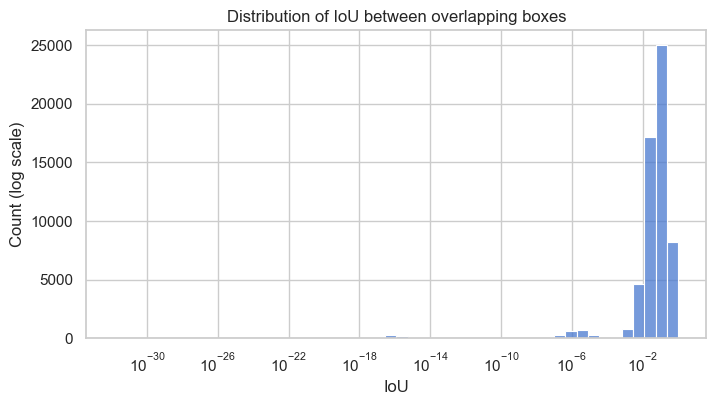

In [7]:
def compute_iou(box1, box2):
    """box format: (x_center, y_center, width, height) normalized"""
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2
    # convert to (x1, y1, x2, y2) absolute
    x1_min = x1 - w1/2
    y1_min = y1 - h1/2
    x1_max = x1 + w1/2
    y1_max = y1 + h1/2
    x2_min = x2 - w2/2
    y2_min = y2 - h2/2
    x2_max = x2 + w2/2
    y2_max = y2 + h2/2
    inter_x1 = max(x1_min, x2_min)
    inter_y1 = max(y1_min, y2_min)
    inter_x2 = min(x1_max, x2_max)
    inter_y2 = min(y1_max, y2_max)
    inter_area = max(0, inter_x2 - inter_x1) * max(0, inter_y2 - inter_y1)
    area1 = w1 * h1
    area2 = w2 * h2
    union = area1 + area2 - inter_area
    return inter_area / union if union > 0 else 0

overlaps = []
for img_id, group in df.groupby("image_id"):
    boxes = group[["x_center", "y_center", "width", "height"]].values
    n = len(boxes)
    if n < 2:
        continue
    for i in range(n):
        for j in range(i+1, n):
            iou = compute_iou(boxes[i], boxes[j])
            overlaps.append(iou)

plt.figure(figsize=(8,4))
sns.histplot(overlaps, bins=50, log_scale=True)
plt.title("Distribution of IoU between overlapping boxes")
plt.xlabel("IoU")
plt.ylabel("Count (log scale)")
plt.show()